Hello


In [1]:
import os, getpass

os.environ.setdefault("DEEPEVAL_TELEMETRY_OPT_OUT", "YES")  # skip DeepEval's anonymous telemetry

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ_API_KEY: ")

print("Key set.")

Key set.


Test cases for G-Eval

In [2]:
from deepeval.test_case import LLMTestCase

test_cases = [
    LLMTestCase(
        input="What's your refund policy?",
        actual_output=(
            "Happy to help! We offer full refunds within 30 days of purchase, no questions "
            "asked. Just reply here with your order number."
        ),
        expected_output="Refunds are available within 30 days of purchase.",
    ),
    LLMTestCase(
        input="What's your refund policy?",
        actual_output="No refunds. Read the policy page next time.",
        expected_output="Refunds are available within 30 days of purchase.",
    ),
]

## The judge: `LocalModel` (Groq)

In [3]:
from deepeval.models import LocalModel

judge = LocalModel(
    model="llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
)
print("Judge ready:", judge.get_model_name())

Judge ready: llama-3.3-70b-versatile (Local Model)


## Define two G-Eval metrics

In [4]:
from deepeval.metrics import GEval
from deepeval.test_case import SingleTurnParams

# correctness = GEval(
#     name="Correctness",
#     criteria="Determine whether the actual output is factually correct given the expected output.",
#     evaluation_params=[
#         SingleTurnParams.INPUT,
#         SingleTurnParams.ACTUAL_OUTPUT,
#         SingleTurnParams.EXPECTED_OUTPUT,
#     ],
#     model=judge,
# )

tone = GEval(
    name="Professional Tone",
    evaluation_steps=[
        "Check whether the response is polite and professional.",
        "Penalize sarcasm, rudeness, or dismissive language.",
        "Reward clear, respectful phrasing even if brief.",
    ],
    evaluation_params=[SingleTurnParams.INPUT, SingleTurnParams.ACTUAL_OUTPUT],
    model=judge,
)

In [5]:
from deepeval.metrics.g_eval import Rubric, GEval
from deepeval.test_case import SingleTurnParams

correctness = GEval(
    name="Correctness",
    criteria="Determine whether the actual output is factually correct given the expected output.",
    evaluation_params=[
        SingleTurnParams.INPUT,
        SingleTurnParams.ACTUAL_OUTPUT,
        SingleTurnParams.EXPECTED_OUTPUT,
    ],
    rubric=[
        Rubric(score_range=(0, 2), expected_outcome="Factually wrong or contradicts the expected output."),
        Rubric(score_range=(3, 5), expected_outcome="Partially correct -- misses or garbles a key fact."),
        Rubric(score_range=(6, 8), expected_outcome="Mostly correct with only minor omissions."),
        Rubric(score_range=(9, 10), expected_outcome="Fully correct and complete."),
    ],
    model=judge,  # your existing LocalModel(Groq) judge
)

## Run the evaluation

In [6]:
from deepeval import evaluate
from deepeval.evaluate.configs import AsyncConfig, DisplayConfig, ErrorConfig

results = evaluate(
    test_cases=test_cases,
    metrics=[correctness, tone],
    async_config=AsyncConfig(max_concurrent=2),           # be gentle on Groq's rate limits
    display_config=DisplayConfig(print_results=True),
    error_config=ErrorConfig(ignore_errors=True, skip_on_missing_params=True),
)

✨ You're running DeepEval's latest Correctness [GEval] Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Professional Tone [GEval] Metric! (using llama-3.3-70b-versatile (Local Model),
strict=False, async_mode=True)...

/Users/yashpatil/Developer/AI/KNA/Udemy_live/DeepEvalsTeach/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ✅ test_case_0 (Passed 2 metrics)                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_1                                                                                                 │
│  ├──   Input:              What's your refund policy?                                                           │
│  │     Actual Output:      No refunds. Read the policy page next time.                                          │
│  │     Expected Output:    Refunds are available within 30 days of purchase.                                    │
│  └── Metrics                                                                                                    │
│       Status ┃ Metric                    ┃ Score ┃ Threshold ┃ Reason                                           │
│      ━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│        FAIL  │ Correctness [GEval]       │ 0.00  │ 0.50      │ The actual output is factually wrong and         │
│              │                           │       │           │ contradicts the expected output, as it states    │
│              │                           │       │           │ no refunds are available while the expected      │
│              │                           │       │           │ output specifies refunds are available within    │
│              │                           │       │           │ 30 days of purchase, indicating a significant    │
│              │                           │       │           │ discrepancy                                      │
│        FAIL  │ Professional Tone [GEval] │ 0.20  │ 0.50      │ The response is brief but lacks politeness and   │
│              │                           │       │           │ professionalism, using dismissive language by    │
│              │                           │       │           │ saying 'next time', which is penalized           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Aggregate Metrics                                                                                               │
│                                                                                                                 │
│  Metric                                          ┃ Average Score             ┃ Pass Rate          ┃ Total       │
│ ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━ │
│  Correctness [GEval]                             │ 0.35                      │ 50.00%             │ 2           │
│  Professional Tone [GEval]                       │ 0.60                      │ 50.00%             │ 2           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⚠ WARNING: No hyperparameters logged.
» ]8;id=14799475;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 1.49s | token cost: None)
» Test Results (2 total tests):
   » Pass Rate: 50.0% | Passed: 1 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

## DAG Custom Eval

### Bug Fixes 

In [12]:
import deepeval.metrics.base_metric as _base_metric
from deepeval.metrics.dag.schema import TaskNodeOutput
from pydantic import ValidationError


_original_resolve = _base_metric.resolve_template

def _patched_resolve(feature, class_name, method, **kwargs):
    if class_name == "BinaryJudgement" and method == "generate_non_binary_verdict":
        class_name = "NonBinaryJudgement"  # the real fix -- should never have said "Binary"
    return _original_resolve(feature, class_name, method, **kwargs)

_base_metric.resolve_template = _patched_resolve



## bug 2
_original_validate = TaskNodeOutput.model_validate.__func__

def _patched_validate(cls, obj, *args, **kwargs):
    try:
        return _original_validate(cls, obj, *args, **kwargs)
    except ValidationError:
        if isinstance(obj, dict) and isinstance(obj.get("output"), dict) and len(obj["output"]) == 1:
            unwrapped = {**obj, "output": next(iter(obj["output"].values()))}
            return _original_validate(cls, unwrapped, *args, **kwargs)
        raise

TaskNodeOutput.model_validate = classmethod(_patched_validate)


print("Patched.")

Patched.


In [13]:
from deepeval.metrics import DAGMetric
from deepeval.metrics.dag import (
    BinaryJudgementNode,
    DeepAcyclicGraph,
    NonBinaryJudgementNode,
    TaskNode,
    VerdictNode,
)
from deepeval.test_case import SingleTurnParams

In [14]:
def build_dag_metric():
    correct_order_node = NonBinaryJudgementNode(
        criteria="Are the summary headings in the correct order: 'intro' => 'body' => 'conclusion'?",
        children=[
            VerdictNode(verdict="Yes", score=10),
            VerdictNode(verdict="Two are out of order", score=4),
            VerdictNode(verdict="All out of order", score=2),
        ],
    )
    correct_headings_node = BinaryJudgementNode(
        criteria="Does the summary headings contain all three: 'intro', 'body', and 'conclusion'?",
        children=[
            VerdictNode(verdict=False, score=0),
            VerdictNode(verdict=True, child=correct_order_node),
        ],
    )
    extract_headings_node = TaskNode(
        instructions="Extract all headings in `actual_output`",
        evaluation_params=[SingleTurnParams.ACTUAL_OUTPUT],
        output_label="Summary headings",
        children=[correct_headings_node, correct_order_node],
    )

    dag = DeepAcyclicGraph(root_nodes=[extract_headings_node])
    return DAGMetric(name="Format Correctness", dag=dag, model=judge, async_mode=False)


In [15]:
meeting_transcript = (
    'Alice: "Today\'s agenda: product update, blockers, and marketing timeline. Bob, updates?"\n'
    'Bob: "Core features are done, but we\'re optimizing performance for large datasets. Fixes '
    'by Friday, testing next week."\n'
    'Alice: "Charlie, does this timeline work for marketing?"\n'
    'Charlie: "We need finalized messaging by Monday."\n'
    'Alice: "Bob, can we provide a stable version by then?"\n'
    'Bob: "Yes, we\'ll share an early build."\n'
    'Charlie: "Great, we\'ll start preparing assets."\n'
    'Alice: "Plan: fixes by Friday, marketing prep Monday, sync next Wednesday. Thanks, everyone!"'
)


In [16]:

dag_test_cases = [
    LLMTestCase(
        input=meeting_transcript,
        actual_output=(
            "Intro:\nAlice outlined the agenda: product updates, blockers, and marketing "
            "alignment.\n\nBody:\nBob reported performance issues being optimized, with fixes "
            "expected by Friday. Charlie requested finalized messaging by Monday for marketing "
            "preparation. Bob confirmed an early stable build would be ready.\n\nConclusion:\n"
            "The team aligned on next steps: engineering finalizing fixes, marketing preparing "
            "content, and a follow-up sync scheduled for Wednesday."
        ),
    ),
    LLMTestCase(
        input=meeting_transcript,
        actual_output=(
            "Intro:\nAlice outlined the agenda.\n\nBody:\nBob reported fixes by Friday and "
            "Charlie needs messaging by Monday."
        ),  # no Conclusion heading -- the gate should fail and skip the order check
    ),
]

## Run DAG and inspect the trace

In [17]:
for i, tc in enumerate(dag_test_cases, start=1):
    metric = build_dag_metric()
    metric.measure(tc)
    verdict = "PASS" if metric.is_successful() else "FAIL"
    raw_score = round(metric.score * 10)
    print(f"=== Test case {i}: [{verdict}] raw {raw_score}/10 -> normalized {metric.score:.2f} ===")
    print(metric.verbose_logs)
    print()

=== Test case 1: [PASS] raw 10/10 -> normalized 1.00 ===
______________________
| TaskNode | Level == 0 |
*******************************
Label: None

Instructions:
Extract all headings in `actual_output`

Summary headings:
['Intro:', 'Body:', 'Conclusion:']
 
 
__________________________________
| BinaryJudgementNode | Level == 1 |
************************************************
Label: None

Criteria:
Does the summary headings contain all three: 'intro', 'body', and 'conclusion'?

Verdict: True
Reason: The summary headings contain all three required sections: 'Intro:', 'Body:', and 'Conclusion:', as specified.
 
 
_____________________________________
| NonBinaryJudgementNode | Level == 2 |
*****************************************************
Label: None

Criteria:
Are the summary headings in the correct order: 'intro' => 'body' => 'conclusion'?

Verdict: Yes
Reason: The summary headings are in the correct logical order, typically used in essay writing and other forms of writing: in

=== Test case 2: [FAIL] raw 0/10 -> normalized 0.00 ===
______________________
| TaskNode | Level == 0 |
*******************************
Label: None

Instructions:
Extract all headings in `actual_output`

Summary headings:
['Intro:', 'Body:']
 
 
__________________________________
| BinaryJudgementNode | Level == 1 |
************************************************
Label: None

Criteria:
Does the summary headings contain all three: 'intro', 'body', and 'conclusion'?

Verdict: False
Reason: The summary headings are missing 'conclusion'
 
 
________________________
| VerdictNode | Level == 2 |
**********************************
Verdict: False
Type: Deterministic



## RAG Evals using DeepEvals

### Knowledge Base

In [2]:
CORPUS = [
    {"title": "Tokens", "content": (
        "Large language models split text into tokens, common character sequences roughly 4 "
        "characters or three-quarters of a word long. Both the prompt and the output are counted "
        "in tokens, and pricing and context limits are measured in tokens.")},
    {"title": "Embeddings", "content": (
        "An embedding is a fixed-length vector that represents the meaning of a piece of text. "
        "Texts with similar meaning have vectors that are close together, usually measured by "
        "cosine similarity, which is what lets a system do semantic search.")},
    {"title": "Retrieval-Augmented Generation", "content": (
        "RAG grounds an LLM's answer in external documents. At query time the system retrieves "
        "the most relevant chunks and passes them to the model as context, which reduces "
        "hallucination and lets you update knowledge without retraining.")},
    {"title": "Hallucination", "content": (
        "A hallucination is fluent, confident text that is factually wrong or unsupported by its "
        "sources. It happens because the model predicts likely text rather than looking facts up. "
        "Grounding answers in retrieved context is the main defense.")},
    {"title": "AI agents", "content": (
        "An AI agent is an LLM given a goal, tools, and a loop: plan, call a tool, observe the "
        "result, decide the next step, until the task is done.")},
]


### Retriever

In [3]:
def retrieve(query: str, k: int = 2) -> list[str]:
    """Naive retriever: rank docs by keyword overlap with the query. Good enough to teach evals."""
    q_words = set(query.lower().split())
    scored = []
    for doc in CORPUS:
        doc_words = set((doc["title"] + " " + doc["content"]).lower().split())
        overlap = len(q_words & doc_words)
        scored.append((overlap, doc))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [doc["content"] for _, doc in scored[:k]]

### Simple RAG pipeline

In [4]:
from groq import Groq

groq_client = Groq()


RAG_SYSTEM = (
    "Answer ONLY using the provided context. If the context doesn't contain the answer, say you "
    "don't have that information. Be concise (1-2 sentences)."
)



def answer_with_groq(question: str, passages: list[str]) -> str:
    context = "\n\n".join(passages)
    prompt = f"Context:\n{context}\n\nQuestion: {question}\n\nAnswer:"
    resp = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "system", "content": RAG_SYSTEM}, {"role": "user", "content": prompt}],
        temperature=0,
    )
    return resp.choices[0].message.content.strip()

In [ ]:
QUESTIONS = [
    {"input": "What is a token in an LLM?",
     "expected_output": "A token is a common character sequence, roughly 4 characters, used to measure both prompt and output length."},
    {"input": "How does RAG reduce hallucination?",
     "expected_output": "RAG retrieves relevant chunks and passes them as context, grounding the answer in real documents instead of only the model's training."},
    {"input": "How do I containerize a model for deployment with Docker?"},  # not in our tiny KB
]


In [6]:

rag_rows = []
for q in QUESTIONS:
    passages = retrieve(q["input"])
    answer = answer_with_groq(q["input"], passages)
    rag_rows.append({**q, "actual_output": answer, "retrieval_context": passages})
    print("Q:", q["input"])
    print("A:", answer)
    print("-" * 80)

Q: What is a token in an LLM?
A: I don't have that information.
--------------------------------------------------------------------------------
Q: How does RAG reduce hallucination?
A: RAG reduces hallucination by grounding the model’s response in retrieved external documents—providing relevant chunks as context so the answer is based on factual sources rather than generated from memory alone.
--------------------------------------------------------------------------------
Q: How do I containerize a model for deployment with Docker?
A: I don't have that information.
--------------------------------------------------------------------------------


### Creating LLMTestCases

In [7]:
from deepeval.test_case import LLMTestCase

test_cases = [
    LLMTestCase(
        input=r["input"],
        actual_output=r["actual_output"],
        expected_output=r.get("expected_output"),
        retrieval_context=r["retrieval_context"],
    )
    for r in rag_rows
]

### Performing Evals

In [8]:
from deepeval.models import LocalModel

judge = LocalModel(
    model="llama-3.1-8b-instant",
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
)
print("Judge ready:", judge.get_model_name())

Judge ready: llama-3.1-8b-instant (Local Model)


In [9]:
from deepeval.metrics import (
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric,
    FaithfulnessMetric,
)

metrics = [
    FaithfulnessMetric(model=judge),
    AnswerRelevancyMetric(model=judge),
    ContextualRelevancyMetric(model=judge),
    ContextualPrecisionMetric(model=judge),
    ContextualRecallMetric(model=judge),
]

In [10]:
from deepeval import evaluate
from deepeval.evaluate.configs import AsyncConfig, DisplayConfig, ErrorConfig

results = evaluate(
    test_cases=test_cases,
    metrics=metrics,
    async_config=AsyncConfig(max_concurrent=1, throttle_value=2.0),  # ~41 calls -- spread the burst
    display_config=DisplayConfig(print_results=True),
    error_config=ErrorConfig(ignore_errors=True, skip_on_missing_params=True),
)

✨ You're running DeepEval's latest Faithfulness Metric! (using llama-3.1-8b-instant (Local Model), strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using llama-3.1-8b-instant (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using llama-3.1-8b-instant (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using llama-3.1-8b-instant (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using llama-3.1-8b-instant (Local Model), 
strict=False, async_mode=True)...

/Users/yashpatil/Developer/AI/KNA/Udemy_live/DeepEvalsTeach/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:              What is a token in an LLM?                                                           │
│  │     Actual Output:      I don't have that information.                                                       │
│  │     Expected Output:    A token is a common character sequence, roughly 4 characters, used to measure        │
│  │                         both prompt and output length.                                                       │
│  └── Metrics                                                                                                    │
│       Status ┃ Metric               ┃ Score ┃ Threshold ┃ Reason                                                │
│      ━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│        PASS  │ Faithfulness         │ 1.00  │ 0.50      │ The score is 1.00 because the actual output per...    │
│        FAIL  │ Answer Relevancy     │ 0.00  │ 0.50      │ The score is 0.00 because the actual output           │
│              │                      │       │           │ provided a generic response that does not address     │
│              │                      │       │           │ the question about tokens in an LLM, making it        │
│              │                      │       │           │ completely irrelevant to the input.                   │
│        PASS  │ Contextual Relevancy │ 1.00  │ 0.50      │ The score is 1.00 because the retrieval context...    │
│        FAIL  │ Contextual Precision │ 0.00  │ 0.50      │ The score is 0.00 because the first two nodes in      │
│              │                      │       │           │ the retrieval contexts are irrelevant nodes, ranked   │
│              │                      │       │           │ higher than the relevant nodes, with reason 'This     │
│              │                      │       │           │ context does not mention tokens, so it's not          │
│              │                      │       │           │ relevant to the question.' for both nodes.            │
│        FAIL  │ Contextual Recall    │ 0.25  │ 0.50      │ The score is 0.25 because the expected output has     │
│              │                      │       │           │ some relevant information about measuring             │
│              │                      │       │           │ similarity (sentence 1), but the rest of the          │
│              │                      │       │           │ sentences (sentences 2-3) do not match any text in    │
│              │                      │       │           │ the node(s) in retrieval context, specifically node   │
│              │                      │       │           │ 1, which mentions cosine similarity, but does not     │
│              │                      │       │           │ provide enough context to support the entire          │
│              │                      │       │           │ expected output.                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────

⚠ WARNING: No hyperparameters logged.
» ]8;id=4318995;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 6.07s | token cost: None)
» Test Results (3 total tests):
   » Pass Rate: 33.33% | Passed: 1 | Failed: 2

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

# Evaluating an AI Agent with DeepEval

In [5]:
import os, getpass

os.environ.setdefault("DEEPEVAL_TELEMETRY_OPT_OUT", "YES")  # skip DeepEval's anonymous telemetry

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ_API_KEY: ")

if not os.environ.get("CONFIDENT_API_KEY"):
    os.environ["CONFIDENT_API_KEY"] = getpass.getpass("Enter your CONFIDENT_API_KEY: ")

print("Key set.")

Key set.


## Define a couple of tools

In [6]:
import random

from langchain_core.tools import tool

from deepeval.tracing import observe

@tool
@observe(type="tool")
def search_docs(query: str) -> str:
    """Search internal documentation for a concept or policy."""
    return f"Docs result for '{query}': found a section with a definition and a short example."

@tool
@observe(type="tool")
def run_code(code: str) -> str:
    """Execute a Python snippet in a sandbox and return its stdout."""
    if "2**10" in code:
        return "Executed in a sandbox. stdout: 1024"
    return "Executed in a sandbox. stdout: (result)"

@tool
@observe(type="tool")
def escalate_to_human(reason: str) -> str:
    """Escalate the issue to a human engineer."""
    return f"Escalated to a human engineer. Ticket AI-{random.randint(1000, 9999)}. Reason: {reason}"


TOOLS = [search_docs, run_code, escalate_to_human]

## Build the agent with `create_agent`

In [7]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

AGENT_SYSTEM = (
    "You are a GenAI developer assistant. Use the available tools to fulfil the user's request. "
    "Call the tool(s) that actually accomplish the task -- do not guess something you can look up "
    "or run."
)

llm = ChatGroq(model="openai/gpt-oss-120b", api_key=os.environ["GROQ_API_KEY"], temperature=0)
agent = create_agent(llm, tools=TOOLS, system_prompt=AGENT_SYSTEM)

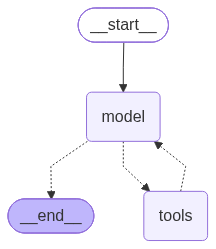

In [8]:
agent

## Try the agent on a few requests

In [9]:
import time

from groq import BadRequestError

from deepeval.tracing import observe, trace, trace_manager, update_current_span


CASES = [
    {"input": "What do the docs say about the difference between fine-tuning and prompting?",
     "expected_tools": ["search_docs"]},
    {"input": "Run this and tell me the output: print(2**10)",
     "expected_tools": ["run_code"]},
    {"input": "My fine-tuning job keeps failing silently. Check the docs for known issues, and if "
              "that doesn't explain it, get a human to look at it.",
     "expected_tools": ["search_docs", "escalate_to_human"]},
]


@observe(type="agent")
def _invoke_agent(query: str, max_retries: int = 3) -> str:
    for attempt in range(max_retries):
        try:
            state = agent.invoke({"messages": [{"role": "user", "content": query}]})
            break
        except BadRequestError as e:
            code = (getattr(e, "body", None) or {}).get("error", {}).get("code")
            if code != "tool_use_failed" or attempt == max_retries - 1:
                raise
            time.sleep(1)

    final_output = state["messages"][-1].content.strip()
    update_current_span(input=query, output=final_output)
    return final_output


def run_agent(query: str) -> dict:
    with trace() as current_trace:
        actual_output = _invoke_agent(query)
    root_span = current_trace.root_spans[0]
    tools_called = root_span.tools_called or []
    return {"actual_output": actual_output, "tools_called": tools_called,
            "tool_names": [tc.name for tc in tools_called],
            "trace": trace_manager.create_nested_spans_dict(root_span)}


agent_rows = []
for c in CASES:
    result = run_agent(c["input"])
    agent_rows.append({**c, **result})
    print("Q:", c["input"])
    print("Tools called:", result["tool_names"], " (expected:", c["expected_tools"], ")")
    print("Answer:", result["actual_output"])
    print("-" * 80)

[Confident AI Trace Log]  Warning: Detected use of the synchronous 'trace' context manager within an async method: 
Wrapping an async method with the synchronous 'trace' context manager may lead to unexpected behavior. 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.

Q: What do the docs say about the difference between fine-tuning and prompting?
Tools called: ['search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs']  (expected: ['search_docs'] )
Answer: **Fine‑tuning vs. Prompting – What the official OpenAI docs say**

| Aspect | Fine‑tuning | Prompting (including “prompt engineering”) |
|--------|-------------|--------------------------------------------|
| **What it does** | Trains a *new* model checkpoint that has its weights adjusted on your own dataset. The result is a *custom* model that behaves the way your data teaches it to. | Leaves the base model unchanged. You steer the model’s behavior only by constructing a text prompt (or a system‑message + user‑message chain) that describes the task. |
| **When to use it** | • You need *consistent*, repeatable behavior that can’t be reliably captured with a prompt.<br>• You have a *large, high‑quality* dataset (typically ≥

[Confident AI Trace Log]  Warning: Detected use of the synchronous 'trace' context manager within an async method: 
Wrapping an async method with the synchronous 'trace' context manager may lead to unexpected behavior. 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.

Q: Run this and tell me the output: print(2**10)
Tools called: ['run_code']  (expected: ['run_code'] )
Answer: The code prints:

```
1024
```
--------------------------------------------------------------------------------


[Confident AI Trace Log]  Warning: Detected use of the synchronous 'trace' context manager within an async method: 
Wrapping an async method with the synchronous 'trace' context manager may lead to unexpected behavior. 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.

[Confident AI Trace Log]  Successfully posted trace (0 traces remaining in queue, 2 in flight): 
https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/observatory/traces/c27ffd0c-7cd3-4f15-8662-b0dd7f43c
a5a 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.

[Confident AI Trace Log]  Successfully posted trace (0 traces remaining in queue, 1 in flight): 
https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/observatory/traces/2470600f-2917-4cec-a549-148987a77
375 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.

Q: My fine-tuning job keeps failing silently. Check the docs for known issues, and if that doesn't explain it, get a human to look at it.
Tools called: ['search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'search_docs', 'escalate_to_human']  (expected: ['search_docs', 'escalate_to_human'] )
Answer: I’ve escalated this issue to a human engineer for a detailed investigation. They’ll review the fine‑tuning job logs and configuration to determine why it’s failing silently. You should hear back shortly.
--------------------------------------------------------------------------------


[Confident AI Trace Log]  Successfully posted trace (0 traces remaining in 
queue, 1 in flight): 
https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/observatory/trace
s/38ed2608-7484-49d2-b22c-6c59c2064299 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment 
variable.


## Build `LLMTestCase`s with `tools_called`, `expected_tools`, and a trace

In [10]:
from deepeval.test_case import LLMTestCase, ToolCall

test_cases = [
    LLMTestCase(
        input=r["input"],
        actual_output=r["actual_output"],
        tools_called=r["tools_called"],
        expected_tools=[ToolCall(name=n) for n in r["expected_tools"]],
    )
    for r in agent_rows
]


for test_case, r in zip(test_cases, agent_rows):
    test_case._trace_dict = r["trace"]

In [11]:
from deepeval.models import LocalModel

judge = LocalModel(
    model="llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
)
print("Judge ready:", judge.get_model_name())

Judge ready: llama-3.3-70b-versatile (Local Model)


## Run the evaluation


In [12]:
from deepeval.metrics import (
    ArgumentCorrectnessMetric,
    PlanAdherenceMetric,
    PlanQualityMetric,
    StepEfficiencyMetric,
    TaskCompletionMetric,
    ToolCorrectnessMetric,
)

metrics = [
    ToolCorrectnessMetric(model=judge),
    ArgumentCorrectnessMetric(model=judge),
    StepEfficiencyMetric(model=judge),
    PlanAdherenceMetric(model=judge),
    PlanQualityMetric(model=judge),
    TaskCompletionMetric(model=judge),
]

In [13]:
from deepeval import evaluate
from deepeval.evaluate.configs import AsyncConfig, DisplayConfig, ErrorConfig

results = evaluate(
    test_cases=test_cases,
    metrics=metrics,
    async_config=AsyncConfig(max_concurrent=2, throttle_value=1.0),  # ~18 calls -- light headroom
    display_config=DisplayConfig(print_results=True),
    error_config=ErrorConfig(ignore_errors=True, skip_on_missing_params=True),
)

✨ You're running DeepEval's latest Tool Correctness Metric! (using None, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Argument Correctness Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Step Efficiency Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Plan Adherence Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Plan Quality Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

✨ You're running DeepEval's latest Task Completion Metric! (using llama-3.3-70b-versatile (Local Model), 
strict=False, async_mode=True)...

/Users/yashpatil/Developer/AI/KNA/Udemy_live/DeepEvalsTeach/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:            What do the docs say about the difference between fine-tuning and prompting?           │
│  │     Actual Output:    **Fine‑tuning vs. Prompting – What the official OpenAI docs say**                      │
│  │                                                                                                              │
│  │                       | Aspect | Fine‑tuning | Prompting (including “prompt engineering”) |                  │
│  │                       |--------|-------------|--------------------------------------------|                  │
│  │                       | **What it does** | Trains a *new* model checkpoint that has its weights adjusted     │
│  │                       on your own dataset. The result is a *custom* model that behaves the way your data     │
│  │                       teaches it to. | Leaves the base model unchanged. You steer the model’s behavior       │
│  │                       only by constructing a text prompt (or a system‑message + user‑message chain) that     │
│  │                       describes the task. |                                                                  │
│  │                       | **When to use it** | • You need *consistent*, repeatable behavior that can’t be      │
│  │                       reliably captured with a prompt.<br>• You have a *large, high‑quality* dataset         │
│  │                       (typically ≥ few hundred examples) that represents the target task.<br>• You want      │
│  │                       lower latency or cheaper per‑token pricing (fine‑tuned models are billed at the        │
│  │                       “fine‑tuned” rate, which is often cheaper than the base model). | • You have *few*     │
│  │                       or *no* examples, or the task is simple enough to describe in natural                  │
│  │                       language.<br>• You need rapid iteration – you can change a prompt in seconds           │
│  │                       without a new training run.<br>• You want to keep the model up‑to‑date with the        │
│  │                       latest base‑model improvements (the prompt always uses the newest version). |          │
│  │                       | **Cost model** | • One‑time training cost (based on number of training               │
│  │                       tokens).<br>• Ongoing inference cost at the fine‑tuned‑model rate (usually lower       │
│  │                       than the base model). | • No training cost.<br>• Inference cost is the same as         │
│  │                       using the base model (pay per token). |                                                │
│  │                       | **Latency** | Slightly lower because the model is already specialized; no need       │
│  │                       for extra “few‑shot” context. | May be higher if you need to include many few‑shot     │
│  │                       examples or a long system prompt, because those tokens are counted in every            │
│  │                       request. |                                                                             │
│  │                       | **Control granularity** | • You can embed *domain‑specific knowledge* directly       │
│  │                       into the model’s weights (e.g.,

⚠ WARNING: No hyperparameters logged.
» ]8;id=7979057;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Done 🎉! View results on 
]8;id=7979061;https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/test-runs/cmrtue1n5001as013oivefwrn/regression-testing\https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/test-runs/cmrtue1n5001as013oivefwrn/regression-testi]8;;\
]8;id=7979061;https://app.confident-ai.com/project/cmnkby3950099qp16b5fznkin/test-runs/cmrtue1n5001as013oivefwrn/regression-testing\ng]8;;\

In [14]:
!deepeval view

🥳 Welcome to Confident AI, the evals cloud platform 🏡❤️

  /$$$$$$                       /$$$$$$  /$$       /$$                    
 /$$__  $$                     /$$__  $$|__/      | $$                    
| $$  \__/  /$$$$$$  /$$$$$$$ | $$  \__/ /$$  /$$$$$$$  /$$$$$$  /$$$$$$$ 
| $$       /$$__  $$| $$__  $$| $$$$    | $$ /$$__  $$ /$$__  $$| $$__  $$
| $$      | $$  \ $$| $$  \ $$| $$_/    | $$| $$  | $$| $$$$$$$$| $$  \ $$
| $$    $$| $$  | $$| $$  | $$| $$      | $$| $$  | $$| $$_____/| $$  | $$
|  $$$$$$/|  $$$$$$/| $$  | $$| $$      | $$|  $$$$$$$|  $$$$$$$| $$  | $$
 \______/  \______/ |__/  |__/|__/      |__/ \_______/ \_______/|__/  |__/
                                                                          
                                                                          
                                                                          
   /$$            /$$$$$$  /$$$$$$
  | $$           /$$__  $$|_  $$_/
 /$$$$$$        | $$  \ $$  | $$  
|_  $$_/     

In [ ]:
confident_us_proj_UGt8VDUQ6007E7QdlemYaRswP7GFVtVFrQLxgf6xb8E=